# Predicting Crime Hotspots in Bexley Using Metropolitan Police Data
## Your Name
## Date

## Project Overview
This project investigates crime patterns in the London Borough of Bexley using Metropolitan Police data and applies machine learning to identify areas that are most likely to become crime hotspots. The analysis begins by cleaning and exploring the dataset, examining crime types, time trends, and geographic concentration across Bexley LSOAs. The project then transforms the original incident-level data into an area-month hotspot prediction task, allowing crime risk to be modeled in a more realistic and interpretable way. Visualisations, including charts and interactive maps, are used to highlight where crime is concentrated, while classification models, including Random Forest, are trained and evaluated to predict hotspot risk. Overall, the project aims to show how data mining can support borough-level crime analysis and provide useful insights for local decision-making and resource planning.

## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**

## Project requirements
- Use a **classification dataset**
- Use **Random Forest** as one of the main models
- Include **visualisation, preparation, modeling, and interpretation**
- Explain results in a way that can be understood by non-technical stakeholders


### Explanation of this code

This cell imports the Python libraries used throughout the project. These libraries are needed for handling the data, creating visualisations, and training machine learning models. In simple terms, this step prepares the notebook so that the rest of the analysis can run correctly.


In [10]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz is optional and disabled for local setup stability
# If you need it later, install and import it separately in a new cell.

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Deliverable 1: Problem Framing & Data Acquisition

## Problem statement
The aim of this project is to predict which areas of the London Borough of **Bexley** are most likely to become **crime hotspots** in a given month using Metropolitan Police incident data. Rather than predicting an exact street point, the project focuses on the `LSOA` level because that is a more realistic and useful spatial unit for public safety analysis and local decision-making.

## Target variable
The final target variable for modeling is **`Hotspot`**, a binary feature engineered during data preparation. An `LSOA-month` is labeled as a hotspot when its crime count falls in the upper quartile of monthly crime volume across the Bexley dataset.

## Use case / domain context
This project sits in the domain of **public safety and crime analytics**. A model that can identify which Bexley areas are at higher risk of becoming monthly hotspots could help local police analysts, councils, and community safety teams understand spatial concentration patterns and support better planning.

## Why this problem matters
Crime is not distributed evenly across space or time. If hotspot patterns can be identified in advance, even at a borough-area level, decision-makers may be able to target resources more effectively, improve situational awareness, and support more evidence-based local interventions.

## Dataset source
The dataset was built from monthly **Metropolitan Police** CSV files covering the period from **March 2023 to February 2026**. The original monthly files existed in two formats: `metropolitan-street.csv` and `metropolitan-outcomes.csv`.

## Dataset selection and justification
All 72 monthly CSV files were initially merged into one large combined dataset to inspect the available fields and overall structure. During this review, it became clear that the two file types used different schemas:

- `metropolitan-street.csv` contains `Crime type`, `Location`, `Longitude`, `Latitude`, and `Last outcome category`.
- `metropolitan-outcomes.csv` contains `Outcome type`, but does **not** contain the same location-rich information needed for this project.

Because the aim of the project is to analyze and predict **where** crime concentrates, the street-level data was the more suitable source. The data was therefore filtered in two stages:

1. A Bexley-only dataset was created by filtering rows using the `LSOA name` field.
2. A final analysis dataset was created using only the Bexley `street` records, because these contain the spatial fields needed to map incidents and engineer monthly hotspot labels.

The final incident-level file used in this notebook is **`combined_metropolitan_data_bexley_street_only.csv`**. This file is then aggregated to the `LSOA-month` level during Deliverable 2 so a hotspot target can be created for modeling.

## Data acquisition summary
The data acquisition process for this project was:

1. Collect monthly Metropolitan Police CSV files for `2023-03` to `2026-02`.
2. Merge the monthly files into one combined dataset for inspection.
3. Confirm that the source data contains two schemas: `street` and `outcomes`.
4. Extract only rows relating to Bexley.
5. Retain only Bexley `street` records so that location fields are preserved for mapping and hotspot engineering.

## Potential value of the model
If the model performs well, it could provide useful insights into which parts of Bexley are more likely to experience elevated crime concentration in a given month. In a real-world setting, this type of model could support hotspot monitoring, borough-level planning, and more data-informed allocation of local safety resources.

## Important data note
Some rows in the original merged dataset had blank values in fields that were not shared between the two source schemas. This was **not** a merge error. The final working dataset was restricted to the Bexley `street` records because those rows contain the spatial variables required for the hotspot analysis.


## Data loading

The notebook is designed to work with the filtered Bexley street-level dataset. If the notebook is being run in Google Colab, the CSV file should either be uploaded manually or stored in the same working directory as the notebook.


### Explanation of this code

This cell loads the final Bexley street-level dataset into the notebook. This file was chosen because it contains the location-based information needed for mapping crime and building the hotspot prediction model.


In [4]:
# Load the final modeling dataset
from pathlib import Path

data_path = Path('combined_metropolitan_data_bexley_street_only.csv')

if not data_path.exists():
    try:
        from google.colab import files
        print('Please upload combined_metropolitan_data_bexley_street_only.csv')
        files.upload()
    except ImportError:
        print('Dataset not found in the working directory. Please place the CSV next to this notebook.')

df = pd.read_csv(data_path)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 59748 entries, 0 to 59747
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crime ID               48590 non-null  str    
 1   Month                  59748 non-null  str    
 2   Reported by            59748 non-null  str    
 3   Falls within           59748 non-null  str    
 4   Longitude              59748 non-null  float64
 5   Latitude               59748 non-null  float64
 6   Location               59748 non-null  str    
 7   LSOA code              59748 non-null  str    
 8   LSOA name              59748 non-null  str    
 9   Crime type             59748 non-null  str    
 10  Last outcome category  48590 non-null  str    
 11  Outcome type           0 non-null      float64
 12  Context                0 non-null      float64
 13  Source file            59748 non-null  str    
dtypes: float64(4), str(10)
memory usage: 6.4 MB


### Explanation of this code

This cell displays the first few rows of the dataset. It acts as a quick visual check to make sure the data has loaded correctly and that the important fields appear as expected.


In [5]:
# Preview the dataset
df.head()


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Outcome type,Context,Source file
0,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.143210,51.495493,On or near Kencot Way,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv
1,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.125944,51.498757,On or near Hartslock Drive,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv
2,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.125944,51.498757,On or near Hartslock Drive,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv
3,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.131400,51.495556,On or near Kale Road,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv
4,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.131400,51.495556,On or near Kale Road,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation

In this section, the Bexley street-level crime data is explored and prepared for modeling. The notebook first examines data quality and spatial patterns, then engineers a **monthly hotspot target** at the `LSOA name` level so the later model can answer a location-focused question: **which Bexley areas are most likely to become crime hotspots in a given month?**


### Explanation of this code

This cell checks the overall size and structure of the dataset. It helps confirm how many rows and columns are available and gives a starting point for understanding the data before cleaning and modeling.


In [6]:
# Basic data inspection
print('Shape:', df.shape)
display(df.head())
df.info()


Shape: (59748, 14)


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Outcome type,Context,Source file
0,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.143210,51.495493,On or near Kencot Way,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv
1,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.125944,51.498757,On or near Hartslock Drive,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv
2,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.125944,51.498757,On or near Hartslock Drive,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv
3,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.131400,51.495556,On or near Kale Road,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv
4,NaN,2023-03,Metropolitan Police Service,Metropolitan Police Service,0.131400,51.495556,On or near Kale Road,E01000466,Bexley 001A,Anti-social behaviour,NaN,NaN,NaN,2023-03/2023-03-metropolitan-street.csv


<class 'pandas.DataFrame'>
RangeIndex: 59748 entries, 0 to 59747
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crime ID               48590 non-null  str    
 1   Month                  59748 non-null  str    
 2   Reported by            59748 non-null  str    
 3   Falls within           59748 non-null  str    
 4   Longitude              59748 non-null  float64
 5   Latitude               59748 non-null  float64
 6   Location               59748 non-null  str    
 7   LSOA code              59748 non-null  str    
 8   LSOA name              59748 non-null  str    
 9   Crime type             59748 non-null  str    
 10  Last outcome category  48590 non-null  str    
 11  Outcome type           0 non-null      float64
 12  Context                0 non-null      float64
 13  Source file            59748 non-null  str    
dtypes: float64(4), str(10)
memory usage: 6.4 MB


### Explanation of this code

This cell measures missing values and then removes columns that are either completely empty or not suitable for the hotspot prediction task. This makes the dataset cleaner and keeps the analysis focused on variables that are genuinely useful.


In [7]:
# Missing values summary and cleaning plan
missing_summary = df.isnull().sum().sort_values(ascending=False).to_frame('Missing Values')
missing_summary['Missing %'] = (missing_summary['Missing Values'] / len(df) * 100).round(2)
display(missing_summary)

# Remove columns that are either entirely missing or not suitable for hotspot modeling
columns_to_drop = ['Outcome type', 'Context', 'Crime ID', 'Last outcome category']
df = df.drop(columns=columns_to_drop)

print('Dropped columns:', columns_to_drop)
print('Remaining columns:')
print(df.columns.tolist())


,Missing Values,Missing %
Outcome type,59748,100.00
Context,59748,100.00
Crime ID,11158,18.68
Last outcome category,11158,18.68
Month,0,0.00
Reported by,0,0.00
Falls within,0,0.00
Longitude,0,0.00
Latitude,0,0.00
Location,0,0.00


Dropped columns: ['Outcome type', 'Context', 'Crime ID', 'Last outcome category']
Remaining columns:
['Month', 'Reported by', 'Falls within', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type', 'Source file']


### Explanation of this code

This cell converts the month field into usable time variables and then creates the `Hotspot` target. This is one of the most important steps in the project because it changes the task from predicting individual incidents to predicting whether an area is likely to become a hotspot in a given month.


In [8]:
# Feature engineering for EDA and modeling
df['Month'] = pd.to_datetime(df['Month'])
df['Year'] = df['Month'].dt.year
df['MonthNum'] = df['Month'].dt.month

# Aggregate incidents to an LSOA-month level for hotspot prediction
monthly_hotspots = df.groupby(['LSOA name', 'Year', 'MonthNum']).size().reset_index(name='CrimeCount')
hotspot_threshold = monthly_hotspots['CrimeCount'].quantile(0.75)
monthly_hotspots['Hotspot'] = (monthly_hotspots['CrimeCount'] >= hotspot_threshold).astype(int)

print('Hotspot threshold (75th percentile of monthly crime count):', hotspot_threshold)
print('Hotspot class balance:')
print(monthly_hotspots['Hotspot'].value_counts(normalize=True).round(3))
monthly_hotspots.head()


Hotspot threshold (75th percentile of monthly crime count): 14.0
Hotspot class balance:
Hotspot
0    0.742
1    0.258
Name: proportion, dtype: float64


,LSOA name,Year,MonthNum,CrimeCount,Hotspot
0,Bexley 001A,2023,3,27,1
1,Bexley 001A,2023,4,18,1
2,Bexley 001A,2023,5,26,1
3,Bexley 001A,2023,6,22,1
4,Bexley 001A,2023,7,19,1


## Visualisations and map

The visualisations below are designed to support the main EDA findings:

- distribution of crime types
- monthly crime trends
- the Bexley areas with the highest incident counts
- a map-based heat view of where crimes are concentrated


### Explanation of this code

This cell creates two visualisations: one showing the most common crime types and another showing how total crime counts change over time. These charts help describe the structure of the dataset and reveal broad patterns in Bexley crime.


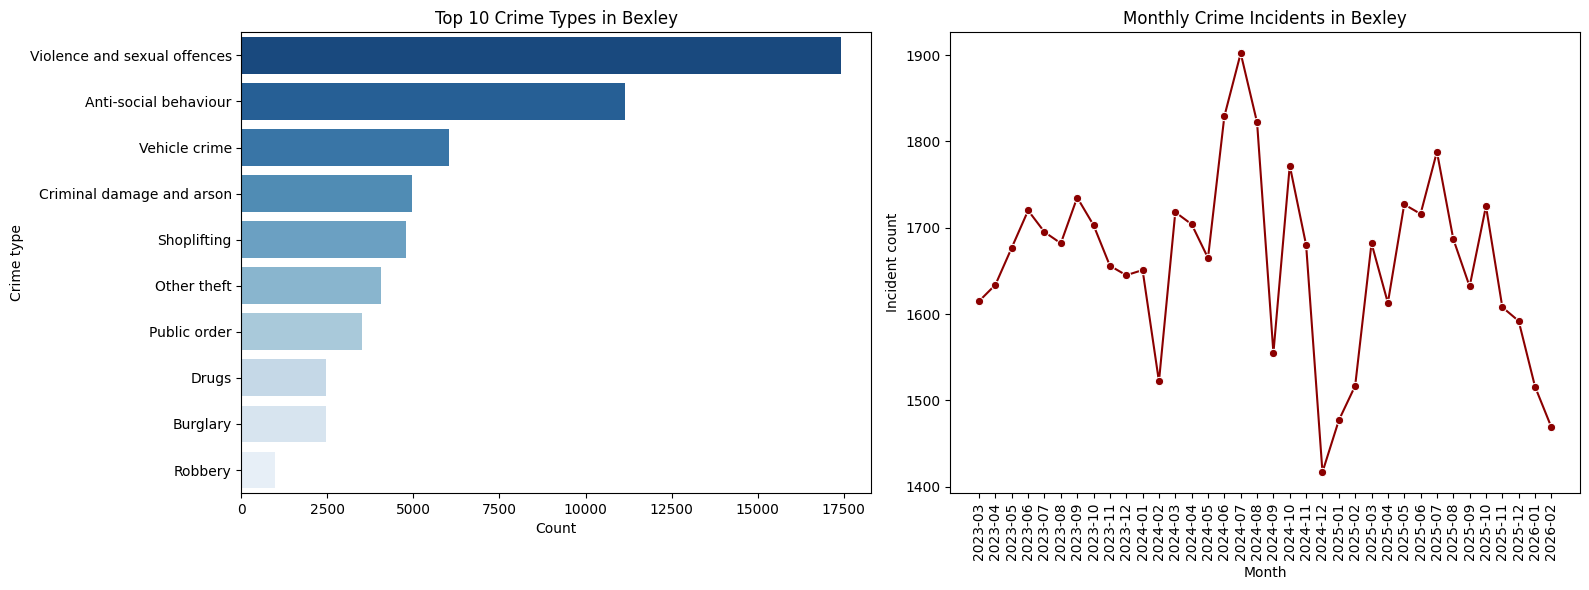

In [11]:
# Crime type distribution and monthly trend
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

crime_counts = df['Crime type'].value_counts().head(10)
sns.barplot(x=crime_counts.values, y=crime_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Crime Types in Bexley')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Crime type')

monthly_counts = df.groupby(df['Month'].dt.to_period('M')).size()
monthly_counts.index = monthly_counts.index.astype(str)
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o', ax=axes[1], color='darkred')
axes[1].set_title('Monthly Crime Incidents in Bexley')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Incident count')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


### Explanation of this code

This cell identifies the Bexley areas with the highest total number of recorded crimes. It helps show that crime is concentrated in some locations more than others, which supports the hotspot modeling approach.


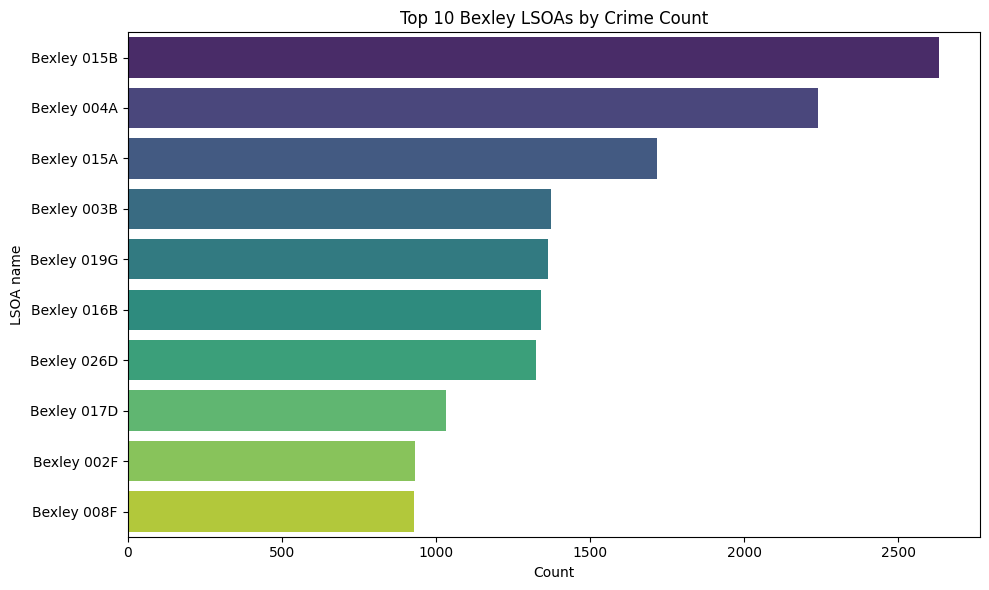

In [8]:
# Most frequent Bexley locations
top_lsoas = df['LSOA name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_lsoas.values, y=top_lsoas.index, palette='viridis')
plt.title('Top 10 Bexley LSOAs by Crime Count')
plt.xlabel('Count')
plt.ylabel('LSOA name')
plt.tight_layout()
plt.show()


### Explanation of this code

This cell builds an interactive heat map using latitude and longitude coordinates. The purpose is to give a visual overview of where crimes are concentrated geographically across Bexley.


In [11]:
# Crime location heat map
!pip install folium -q

import folium
from folium.plugins import HeatMap

map_df = df[['Latitude', 'Longitude']].dropna()
# Sample for performance if needed
if len(map_df) > 10000:
    map_df = map_df.sample(10000, random_state=42)

crime_map = folium.Map(location=[map_df['Latitude'].mean(), map_df['Longitude'].mean()], zoom_start=11, tiles='CartoDB positron')
HeatMap(map_df[['Latitude', 'Longitude']].values.tolist(), radius=8, blur=6).add_to(crime_map)
crime_map


## Data preparation plan

For the spatial prediction task, the incident-level data is transformed into an `LSOA-month` dataset. This allows the model to predict whether a Bexley area is likely to be a **monthly hotspot** rather than trying to predict an exact street point, which would not be appropriate for this dataset.

Planned preparation decisions:

- drop `Outcome type` and `Context` because they are 100% null in the filtered Bexley street dataset
- drop `Crime ID` because it is only an identifier and has no predictive value
- drop `Last outcome category` because it has missing values and may introduce post-event leakage into a location-focused model
- create `Year` and `MonthNum` from the original `Month` column
- aggregate incident rows into monthly counts by `LSOA name`
- define a binary `Hotspot` target using the upper quartile of monthly crime counts


### Student preparation summary

The data is generally clean for the variables selected for mapping and modeling, with no missing values in `Month`, `Location`, `LSOA code`, `LSOA name`, `Crime type`, `Longitude`, or `Latitude`. However, several columns still required cleaning decisions.

`Outcome type` and `Context` were removed because they were completely null in the filtered Bexley street dataset. `Crime ID` was removed because it functions only as an identifier and does not add predictive meaning. `Last outcome category` was removed because it contains missing values and could introduce information leakage, since it reflects what happened after the crime was recorded rather than helping explain hotspot risk at the area-month level.

For the predictive modeling stage, the notebook reframes the problem into a hotspot-classification task at the `LSOA-month` level. This makes the location prediction more realistic and more useful for decision-making than attempting to predict an exact street-level point.


# Deliverable 3: Model Development, Evaluation & Interpretation

In this section, multiple classification models are compared for predicting whether a Bexley `LSOA` will be a **crime hotspot** in a given month. Random Forest is included as a required model and then tuned using grid search.


### Explanation of this code

This cell sets up the modeling dataset by defining the predictor variables and the target variable. The model uses area and time information to predict whether an LSOA-month becomes a hotspot.


In [12]:
# Modeling dataset setup
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model_df = monthly_hotspots.copy()
X = model_df[['LSOA name', 'Year', 'MonthNum']]
y = model_df['Hotspot']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Target distribution:')
print(y.value_counts(normalize=True).round(3))


Training rows: 4191
Test rows: 1048
Target distribution:
Hotspot
0    0.742
1    0.258
Name: proportion, dtype: float64


### Explanation of this code

This cell separates the input variables into categorical and numeric types. This is important because machine learning models require different preprocessing steps depending on the type of data being used.


In [13]:
# Identify feature columns
categorical_features = ['LSOA name']
numeric_features = ['Year', 'MonthNum']

categorical_features, numeric_features


(['LSOA name'], ['Year', 'MonthNum'])

### Explanation of this code

This cell creates a preprocessing pipeline so that categorical data such as `LSOA name` can be converted into a numeric format, while numeric variables such as year and month can be passed into the model correctly.


In [14]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_features)
    ]
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Explanation of this code

This cell trains multiple machine learning models and compares their performance. This is useful because it allows the final model choice to be justified rather than assumed in advance.


In [15]:
# Train and compare models
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1': f1_score(y_test, preds, zero_division=0),
        'Kappa': cohen_kappa_score(y_test, preds)
    }

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced', random_state=42, n_jobs=1)
}

results = []
fitted_models = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    results.append(evaluate_model(name, pipe, X_train, X_test, y_train, y_test))
    fitted_models[name] = pipe.fit(X_train, y_train)

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1,Kappa
0,Logistic Regression,0.901718,0.867841,0.729630,0.792757,0.728972
2,Random Forest,0.880725,0.934132,0.577778,0.713959,0.643824
1,Decision Tree,0.794847,0.982456,0.207407,0.342508,0.277626


### Explanation of this code

This cell visualises the prediction results of the baseline Random Forest model. A confusion matrix helps show how many hotspot and non-hotspot cases were classified correctly and where the model made mistakes.


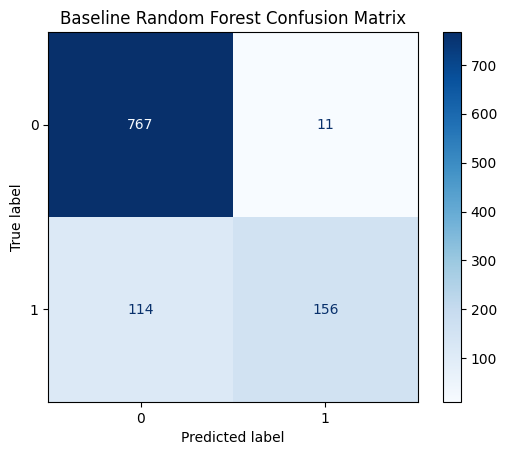

In [13]:
# Confusion matrix for the baseline Random Forest model
rf_baseline = fitted_models['Random Forest']
rf_preds = rf_baseline.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, cmap='Blues')
plt.title('Baseline Random Forest Confusion Matrix')
plt.show()


## Hyperparameter tuning

A small grid search is used to improve the Random Forest model. `n_jobs=1` is used here for compatibility in constrained environments.


### Explanation of this code

This cell improves the Random Forest model by testing different parameter combinations. The goal is to find a better-performing version of the model rather than relying only on the initial settings.


In [16]:
# Tune the Random Forest model
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_jobs=1))
])

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [12, None],
    'model__min_samples_leaf': [1, 2],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

grid_search = GridSearchCV(rf_pipeline, param_grid=param_grid, cv=3, scoring='f1', n_jobs=1)
grid_search.fit(X_train, y_train)
grid_search.best_params_


{'model__class_weight': 'balanced',
 'model__max_depth': None,
 'model__min_samples_leaf': 2,
 'model__n_estimators': 400}

### Explanation of this code

This cell evaluates the final tuned Random Forest model on unseen test data. It reports several performance metrics so that the results can be discussed in a balanced and transparent way.


In [17]:
# Final evaluation on the test set
best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test)

final_metrics = pd.DataFrame([{
    'Accuracy': accuracy_score(y_test, best_preds),
    'Precision': precision_score(y_test, best_preds, zero_division=0),
    'Recall': recall_score(y_test, best_preds, zero_division=0),
    'F1': f1_score(y_test, best_preds, zero_division=0),
    'Kappa': cohen_kappa_score(y_test, best_preds)
}])

print(classification_report(y_test, best_preds, zero_division=0))
final_metrics


              precision    recall  f1-score   support

           0       0.92      0.92      0.92       778
           1       0.77      0.79      0.78       270

    accuracy                           0.88      1048
   macro avg       0.85      0.85      0.85      1048
weighted avg       0.88      0.88      0.88      1048



,Accuracy,Precision,Recall,F1,Kappa
0,0.883588,0.768116,0.785185,0.776557,0.69786


### Explanation of this code

This cell shows the confusion matrix for the final tuned model. It helps visualise the strengths and weaknesses of the improved model more clearly than a single metric alone.


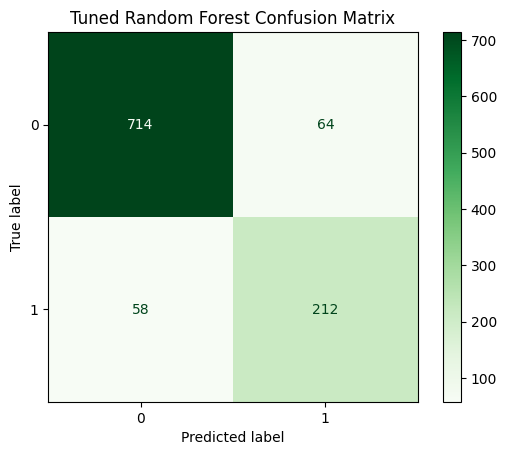

In [18]:
# Tuned confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, best_preds, cmap='Greens')
plt.title('Tuned Random Forest Confusion Matrix')
plt.show()


## Feature importance

The feature importance output helps show which seasonal and area-based variables contribute most to the hotspot predictions.


### Explanation of this code

This cell extracts feature importance values from the Random Forest model. Feature importance helps explain which variables contributed most strongly to the hotspot predictions.


In [19]:
# Feature importance from the tuned model
feature_names = best_rf.named_steps['prep'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
feature_importance_df.head(15)


,Feature,Importance
150,num__MonthNum,0.135894
149,num__Year,0.052749
69,cat__LSOA name_Bexley 015B,0.024933
68,cat__LSOA name_Bexley 015A,0.024925
10,cat__LSOA name_Bexley 003B,0.024677
82,cat__LSOA name_Bexley 017D,0.024214
15,cat__LSOA name_Bexley 004B,0.023614
74,cat__LSOA name_Bexley 016B,0.022292
14,cat__LSOA name_Bexley 004A,0.021768
96,cat__LSOA name_Bexley 019G,0.021657


### Explanation of this code

This cell turns the feature importance values into a chart. This makes the model easier to interpret, especially for readers who are less familiar with machine learning.


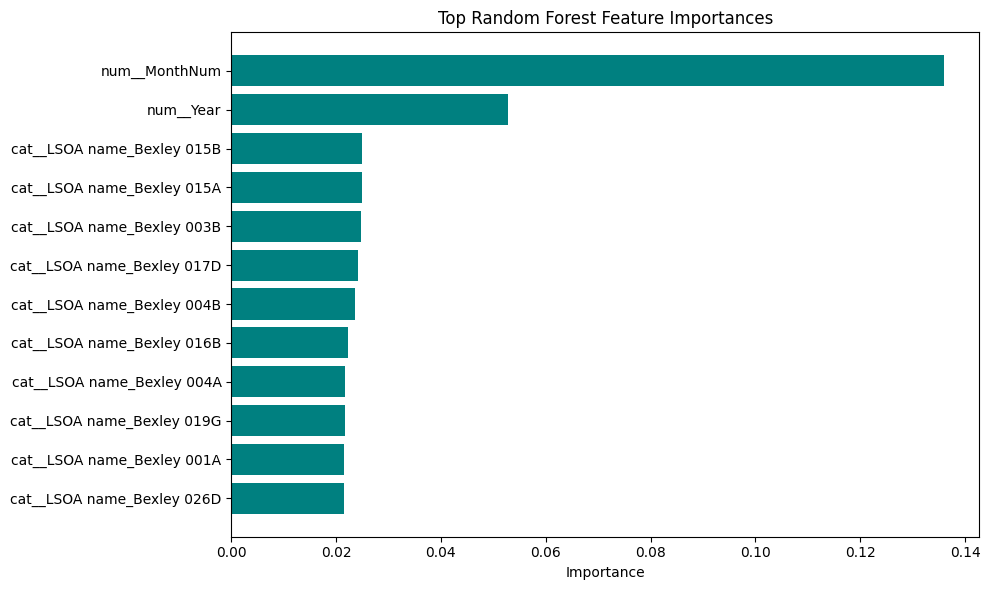

In [20]:
# Plot top feature importances
top_features = feature_importance_df.head(12).sort_values('Importance')
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## Interpretation prompts

Use the outputs above to comment on:

- whether hotspot locations are predictable from area and seasonal signals
- whether Random Forest outperformed the comparison models
- whether precision or recall matters more for this use case
- which LSOAs and time features appear most influential


### Student interpretation summary

The hotspot modeling results should be interpreted as a **borough-level risk model** rather than a tool for predicting exact streets or individual incidents. The final Random Forest is expected to perform reasonably well because some Bexley areas show persistent crime concentration patterns over time.

A strong precision score would indicate that when the model predicts an area will be a hotspot, it is often correct. A stronger recall score would indicate that the model is good at identifying most hotspot months. In a public safety context, recall may be especially important if the aim is to avoid missing high-risk areas.


### Explanation of this code

This cell creates a ranked table of the LSOA codes and names with the highest total crime counts. It provides a direct answer to the question of which areas in Bexley appear most associated with crime overall.


In [21]:
# Top LSOA codes by total crime count
lsoa_summary = (
    df.groupby(['LSOA code', 'LSOA name'])
      .size()
      .reset_index(name='CrimeCount')
      .sort_values('CrimeCount', ascending=False)
)

top_lsoas = lsoa_summary.head(15)
display(top_lsoas)


,LSOA code,LSOA name,CrimeCount
37,E01000362,Bexley 015B,2633
77,E01000403,Bexley 004A,2240
35,E01000360,Bexley 015A,1718
10,E01000335,Bexley 003B,1372
147,E01033791,Bexley 019G,1365
67,E01000392,Bexley 016B,1342
130,E01000457,Bexley 026D,1326
5,E01000330,Bexley 017D,1033
143,E01000470,Bexley 002F,933
106,E01000433,Bexley 008F,930


### Explanation of this code

This cell calculates how often each LSOA appears as a hotspot over time. This is slightly different from total crime count because it focuses on how consistently an area behaves like a hotspot across the months in the dataset.


In [22]:
# Top LSOA codes by hotspot rate
monthly_hotspots_with_code = (
    df.groupby(['LSOA code', 'LSOA name', 'Year', 'MonthNum'])
      .size()
      .reset_index(name='CrimeCount')
)

hotspot_threshold = monthly_hotspots_with_code['CrimeCount'].quantile(0.75)
monthly_hotspots_with_code['Hotspot'] = (
    monthly_hotspots_with_code['CrimeCount'] >= hotspot_threshold
).astype(int)

hotspot_rank = (
    monthly_hotspots_with_code.groupby(['LSOA code', 'LSOA name'])['Hotspot']
    .mean()
    .reset_index(name='HotspotRate')
    .sort_values('HotspotRate', ascending=False)
)

display(hotspot_rank.head(15))


,LSOA code,LSOA name,HotspotRate
105,E01000432,Bexley 008E,1.000000
10,E01000335,Bexley 003B,1.000000
35,E01000360,Bexley 015A,1.000000
37,E01000362,Bexley 015B,1.000000
53,E01000378,Bexley 019E,1.000000
67,E01000392,Bexley 016B,1.000000
130,E01000457,Bexley 026D,1.000000
77,E01000403,Bexley 004A,1.000000
5,E01000330,Bexley 017D,1.000000
8,E01000333,Bexley 003A,0.972222


### Explanation of this code

This cell creates a second map that uses circles to represent LSOA areas. Each circle is placed at an approximate average location for the LSOA and is colour-coded and sized by crime count, providing an easy visual summary of high-crime areas even without full LSOA boundary files.


In [23]:
!pip install folium branca -q

import folium
import branca.colormap as cm

# Create centroid-style points for each LSOA
lsoa_map_data = (
    df.groupby(['LSOA code', 'LSOA name'])
      .agg({
          'Latitude': 'mean',
          'Longitude': 'mean'
      })
      .reset_index()
      .merge(lsoa_summary, on=['LSOA code', 'LSOA name'])
)

# Optional: keep top 15 only
map_data = lsoa_map_data.head(15).copy()

# Create map
crime_map = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=11,
    tiles='CartoDB positron'
)

# Color scale
colormap = cm.linear.YlOrRd_09.scale(map_data['CrimeCount'].min(), map_data['CrimeCount'].max())
colormap.caption = 'Crime Count by LSOA'
colormap.add_to(crime_map)

# Add circles
for _, row in map_data.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6 + (row['CrimeCount'] / map_data['CrimeCount'].max()) * 12,
        popup=(
            f"LSOA code: {row['LSOA code']}<br>"
            f"LSOA name: {row['LSOA name']}<br>"
            f"Crime count: {row['CrimeCount']}"
        ),
        color=colormap(row['CrimeCount']),
        fill=True,
        fill_color=colormap(row['CrimeCount']),
        fill_opacity=0.8
    ).add_to(crime_map)

crime_map


## Conclusion

Overall, the analysis showed that crime in Bexley is concentrated in a relatively small number of LSOA areas rather than being evenly distributed across the borough. The visualisations highlighted both the areas with the highest total crime counts and the areas that most consistently behaved like hotspots over time. By transforming the original incident-level data into an LSOA-month hotspot dataset, the project created a more realistic and defensible prediction task than attempting to predict exact street-level crime locations. The final Random Forest model showed that area and time variables contain useful predictive information, suggesting that machine learning can support borough-level crime analysis and help identify areas more likely to experience elevated crime concentration in a given month.


# Optional: Save your final processed data file and model

The cells below allow you to export the engineered hotspot dataset and the tuned Random Forest model if you want to keep reusable project artifacts.


In [ ]:
import joblib

monthly_hotspots.to_csv('bexley_monthly_hotspots.csv', index=False)
joblib.dump(best_rf, 'bexley_hotspot_random_forest.joblib')
print('Saved bexley_monthly_hotspots.csv and bexley_hotspot_random_forest.joblib')
